## Identitas Diri

Rafi Noufal Dwi Sutrisno

# Mini Project I (disertai revisi perbaikan yang disarankan)

## Set Up

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.initializers import HeNormal, GlorotNormal
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version :", tf.__version__)
print("Setup complete.")

TensorFlow version : 2.20.0
Setup complete.


## Load Dataset

In [ ]:
!wget -O dataset.zip prashanthbairu/delaney-solubility-with-descriptors
!kaggle datasets download -d prashanthbairu/delaney-solubility-with-descriptors
!unzip delaney-solubility-with-descriptors.zip

--2026-06-24 10:35:11--  http://prashanthbairu/delaney-solubility-with-descriptors
Resolving prashanthbairu (prashanthbairu)... failed: Name or service not known.
wget: unable to resolve host address ‘prashanthbairu’
Dataset URL: https://www.kaggle.com/datasets/prashanthbairu/delaney-solubility-with-descriptors
License(s): unknown
100% 15.0k/15.0k [00:00<00:00, 31.3MB/s]

Archive:  delaney-solubility-with-descriptors.zip
  inflating: delaney_solubility_with_descriptors.csv  


In [ ]:
df = pd.read_csv('delaney_solubility_with_descriptors.csv')
df.head()

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
0,2.5954,167.850,0.0,0.0,-2.18
1,2.3765,133.405,0.0,0.0,-2.00
2,2.5938,167.850,1.0,0.0,-1.74
3,2.0289,133.405,1.0,0.0,-1.48
4,2.9189,187.375,1.0,0.0,-3.04


### Penjelasan Load Dataset

#### Ini merupakan rekomendasi perbaikan terkait penjelasan data yang diambil, referensi pengambilan data, dan tujuan pengujian yang akan dirancang.

Ini adalah data dari Bairu Prashanth berupa  data fisikokimia berupa senyawa kimia yang digunakan untuk memprediksi kelarutan dari suatu zat di dalam air yang diambil langsung dari Kaggle menggunakan Kaggle API command. Data ini digunakan

    *Dataset ini berisi informasi sifat kimia dan struktur molekul untuk memprediksi tingkat kelarutan zat organik di dalam air.*

**a. Parameter MolLogP(Octanol-Water Partition Coefficient)**: Mengukur seberapa besar suka (berikatan) senyawa kimia dengan terhadap minyak/lemak dibandingkan air.

**b. Parameter MolWt (Molecular Weight)**: Berat molekul dari senyawa tersebut.

**c. NumRotatableBonds** : Jumlah ikatan tunggal di dalam molekul yang bisa berputar bebas.

**d. AromaticProportion**: Proporsi bagian molekul yang memiliki struktur cincin aromatik.

**e. LogS (logaritma of Aqueous Solubility)**: Nilai Logaritma dari kelarutan zat di dalam air (mol/L). semakin kecil, semakin sulit larut di dalam air.

## Data Preprocessing

### Melihat Nilai Missing Value

In [ ]:
df_data = df.copy()
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1144 entries, 0 to 1143
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MolLogP             1144 non-null   float64
 1   MolWt               1144 non-null   float64
 2   NumRotatableBonds   1144 non-null   float64
 3   AromaticProportion  1144 non-null   float64
 4   logS                1144 non-null   float64
dtypes: float64(5)
memory usage: 44.8 KB


In [ ]:
kolom_kosong = pd.DataFrame({
    'Jumlah Kolom Kosong' : df_data.isnull().sum(),
    'Persentase Kolom Kosong' : df_data.isnull().sum() / df_data.shape[0] * 100
})
kolom_kosong

,Jumlah Kolom Kosong,Persentase Kolom Kosong
MolLogP,0,0.0
MolWt,0,0.0
NumRotatableBonds,0,0.0
AromaticProportion,0,0.0
logS,0,0.0


Dari hasil pengecekan awal, tidak ada nilai missing value berdasarkan dari informasi yang ditampilkan.

### Mengecek Data yang terduplikat

In [ ]:
df_data.duplicated().sum()

np.int64(15)

In [ ]:
duplikasi_data = df_data[df_data.duplicated(keep=False)].sort_values(by=list(df_data.columns))

duplikasi_data

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
1013,0.47660,80.090,0.0,1.000000,1.100
1015,0.47660,80.090,0.0,1.000000,1.100
339,0.70040,232.239,2.0,0.352941,-2.322
946,0.70040,232.239,2.0,0.352941,-2.322
196,0.76140,70.091,1.0,0.000000,0.320
1071,0.76140,70.091,1.0,0.000000,0.320
1118,0.82100,380.662,2.0,0.300000,-2.680
1120,0.82100,380.662,2.0,0.300000,-2.680
713,1.40080,124.139,1.0,0.666667,-1.960
896,1.40080,124.139,1.0,0.666667,-1.960


Terdapat data yang terduplikasi, oleh karena itu perlu di drop agar model yang dibangun akan menggenarilasasi hasil (output) yang baik, bukan sekadar hanya mengingat data yang sama.

In [ ]:
df_data = df.drop_duplicates()
df_data.duplicated().sum()

np.int64(0)

Setelah dilakukan drop, tidak terlihat data duplikat sehingga dapat dilakukan proses lebih lanjut.

### Stastika Dasar

In [ ]:
list_data = ['MolLogP', 'MolWt', 'NumRotatableBonds', 'AromaticProportion', 'logS']
for col in list_data:
  rerata = df_data[col].mean()
  median = df_data[col].median()
  modus = df_data[col].mode()[0]
  print(f"Rata-Rata {col}:{rerata:.2f}")
  print(f"Median {col}:{median:.2f}")
  print(f"Modus {col}:{modus:.2f}")
  print("==="*10)

Rata-Rata MolLogP:2.45
Median MolLogP:2.35
Modus MolLogP:1.41
Rata-Rata MolWt:204.65
Median MolWt:183.17
Modus MolWt:102.18
Rata-Rata NumRotatableBonds:2.18
Median NumRotatableBonds:1.00
Modus NumRotatableBonds:0.00
Rata-Rata AromaticProportion:0.36
Median AromaticProportion:0.38
Modus AromaticProportion:0.00
Rata-Rata logS:-3.06
Median logS:-2.89
Modus logS:-1.96


Statistika dasar ini berguna untuk mengetahui/mengeksplor data awal. Pada NumRotatableBonds dan AromaticProportion nilai modus nya yakni 0.00. Nilai ini menunjukkan Pada kolom NumRotatableBonds modus 0.00 menunjukkan kebanyakan senyawa tidak memiliki ikatan yang dapat berputar, sehingga senyawa tersebut memiliki molekul yang kaku.

Selain itu, nilai 0.00 pada modus AromaticProportion menunjukkan kebanyakan senyawa tidak memiliki cincin aromatik yang umumnya bersifat hidrofobik, sehingga memiliki kelarutan yang bervariasi.

## Feature Engineering

### Handling Outlier

#### Cek Distribusi Data melalui Coefficient Of Skewness

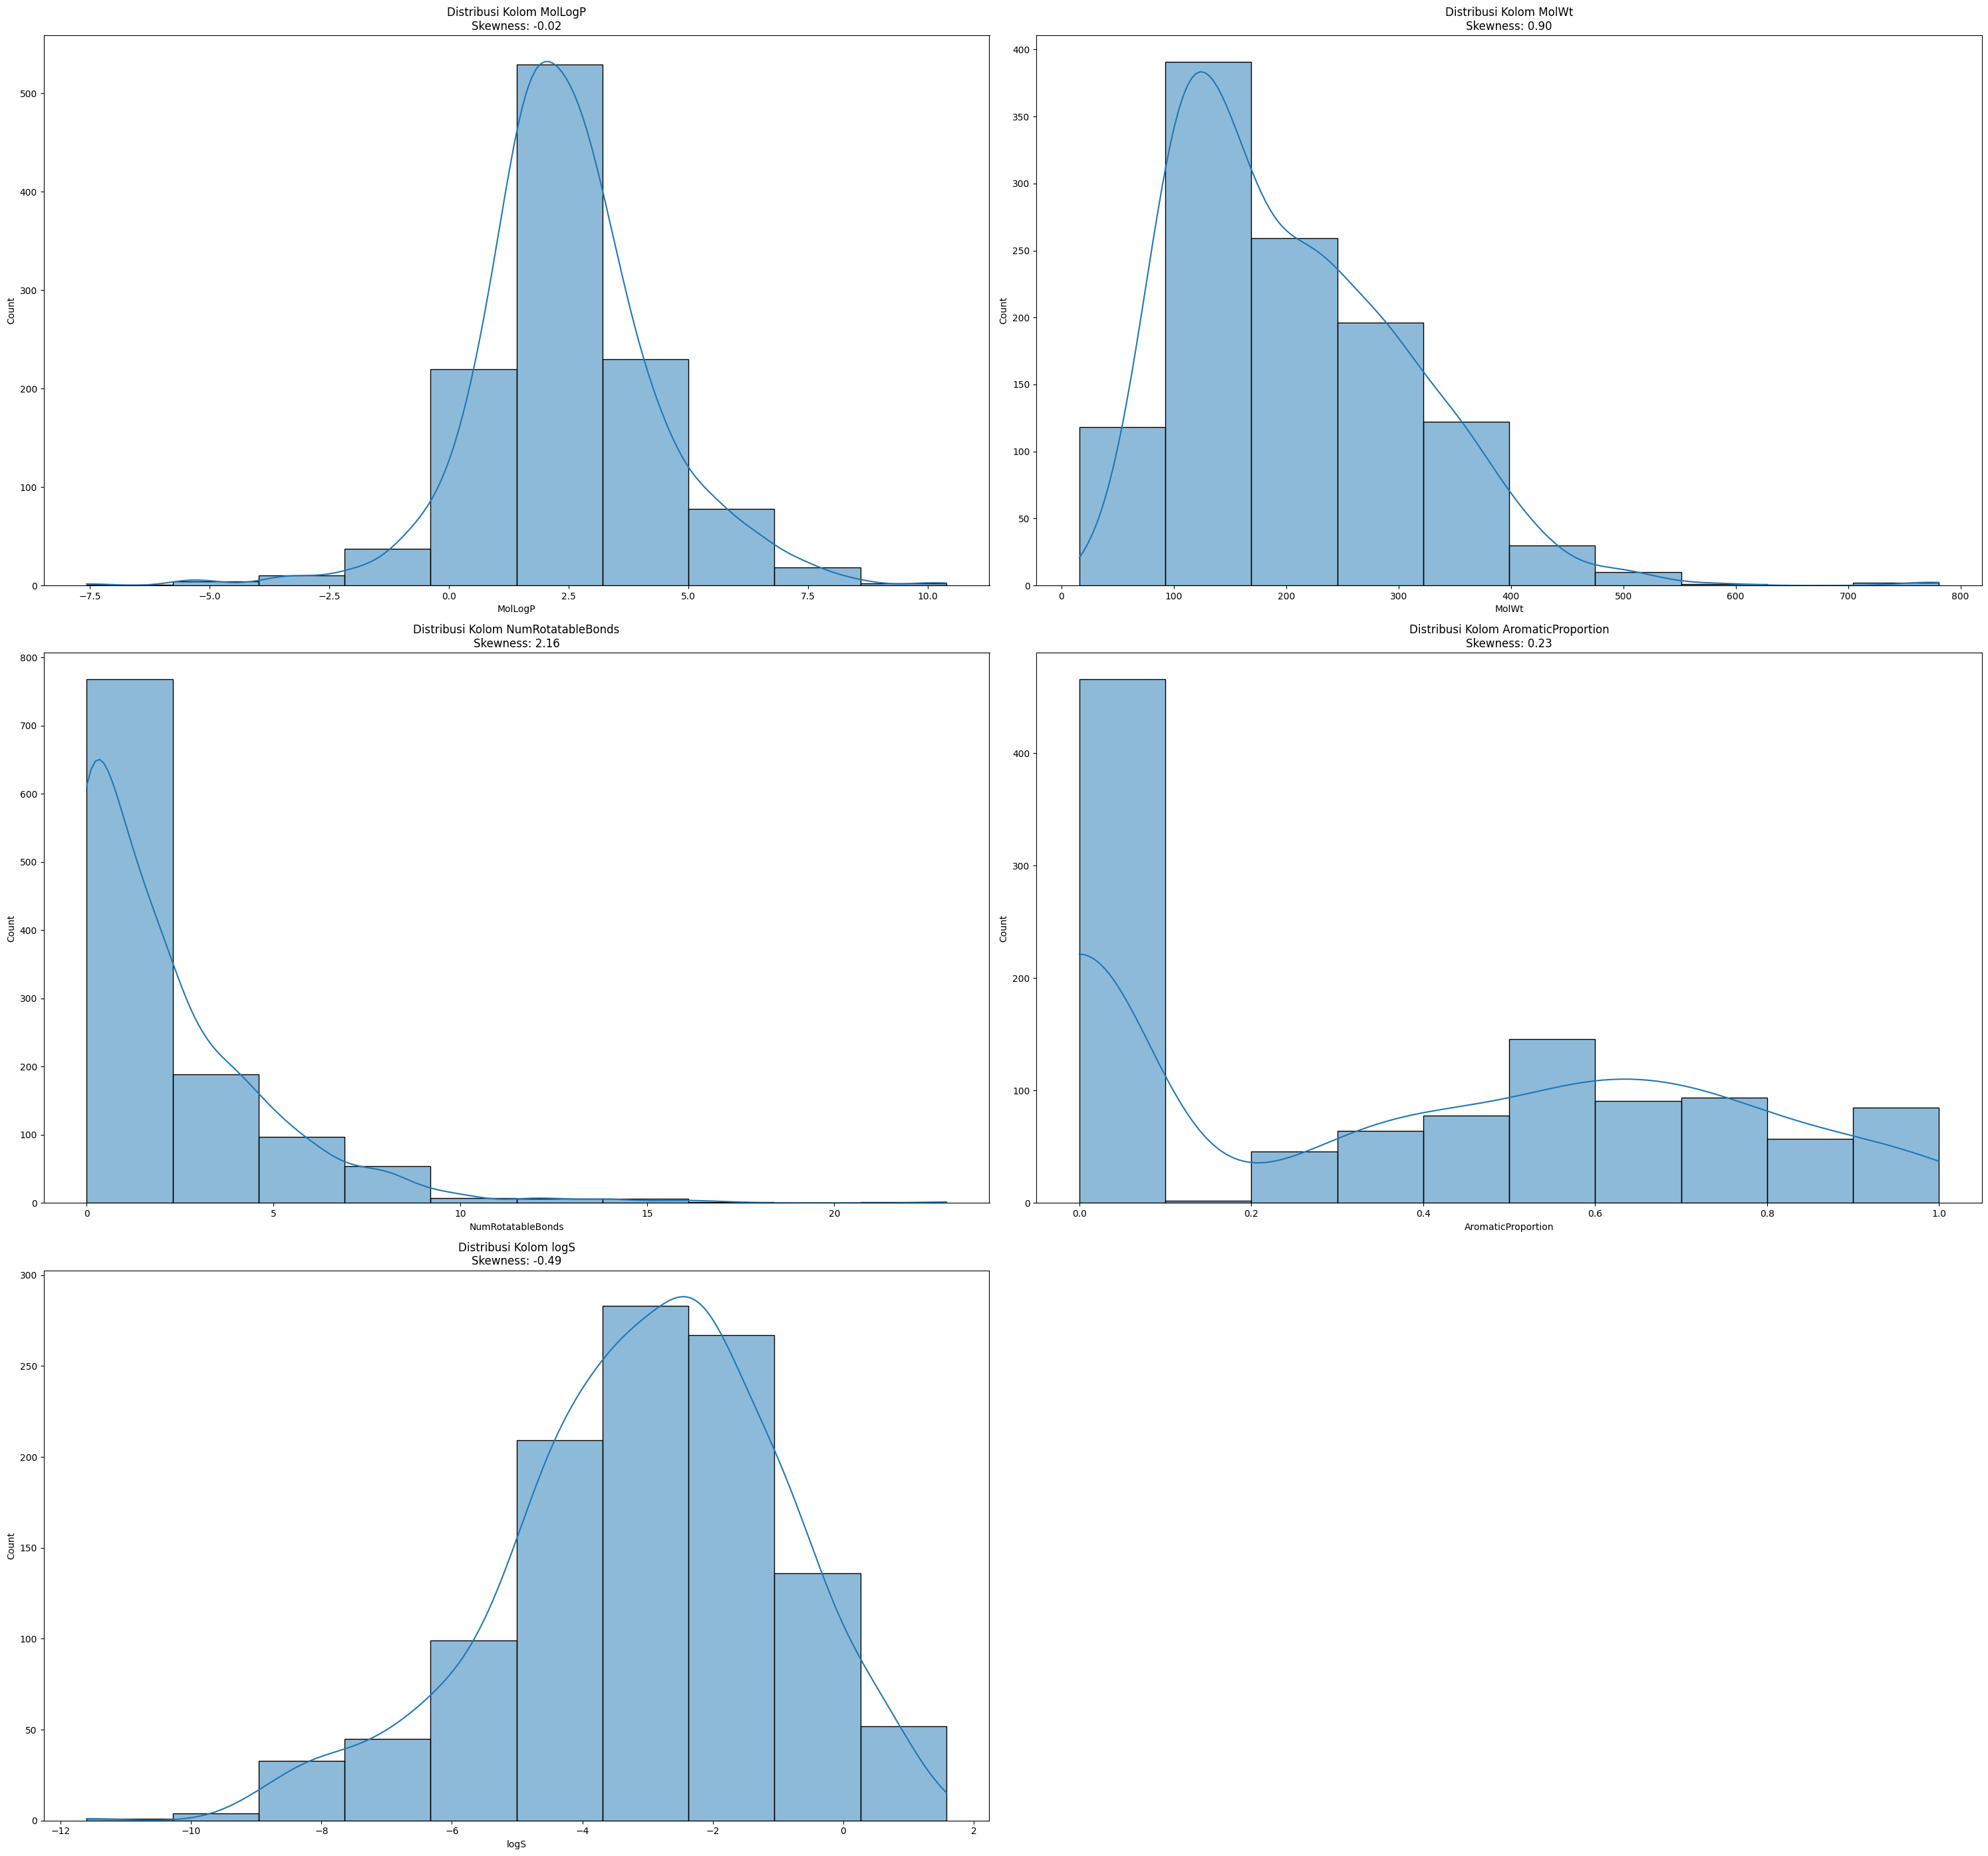

In [ ]:
# Mendefinisikan gambar
fig, ax = plt.subplots(3,2, figsize=(30,28))
for i, col in enumerate (list_data):
  baris = i//2
  kolom = i%2
  sns.histplot(data=df_data, x=col, ax=ax[baris,kolom], kde=True, bins=10)
  ax[baris, kolom].set_title(f'Distribusi Kolom {col}\nSkewness: {df_data[col].skew():.2f}')

#Hapus kotak kosong yang tidak memiliki grafik
fig.delaxes(ax[2,1])

plt.tight_layout()
plt.show()

In [ ]:
for col in list_data:
  normal_dist = df_data[col].skew()
  if normal_dist<-1:
    print(f'kolom{col} : Distribusi sangat miring ke kiri(negatif)')
  elif normal_dist>1:
    print(f'kolom{col} : Distribusi sangat miring ke kanan(positif)')
  elif normal_dist>0.5 and normal_dist<=1:
    print(f'kolom{col} : Distribusi cukup miring ke kanan(positif)')
  elif normal_dist>-0.5 and normal_dist<-1:
    print(f'kolom{col} : Distribusi cukup miring ke kiri(negatif)')
  else:
    print(f'kolom{col} : Distribusi normal')

kolomMolLogP : Distribusi normal
kolomMolWt : Distribusi cukup miring ke kanan(positif)
kolomNumRotatableBonds : Distribusi sangat miring ke kanan(positif)
kolomAromaticProportion : Distribusi normal
kolomlogS : Distribusi normal


Dari penggambaran grafik, terdapat kolom yang berdistribusi normal yakni coloumn MolLogP dan Kolom LogS karana ada yang coefficient of skewness yang bernilai diantara (-0,5<c<0,5).

Namun dibutuhkan pengecekan nilai p-value untuk mengetahui validasi apakah data tersebut berdistribusi normal atau skew.

#### Check Distribusi Data dengan aturan D'Agostino's K^2 Test dan Shapiro-Wilk Test

##### Aturan p-value menggunakan aturan D'Agostinos K^2 Test

In [ ]:
kolom_berdistribusi_normal = []
kolom_berdistribusi_miring = []
for col in list_data:
  res = stats.normaltest(df_data[col])
  if res.pvalue > 0.05:
    kolom_berdistribusi_normal.append(col)
    print(f'kolom {col} berdistribusi secara normal')
  else:
    kolom_berdistribusi_miring.append(col)
    print(f'kolom {col} tidak berdistribusi secara normal')
    print(f'p-value {col}: {res.pvalue}')

kolom MolLogP tidak berdistribusi secara normal
p-value MolLogP: 3.6539631154039967e-16
kolom MolWt tidak berdistribusi secara normal
p-value MolWt: 1.6007203623628627e-32
kolom NumRotatableBonds tidak berdistribusi secara normal
p-value NumRotatableBonds: 2.6784098449589375e-119
kolom AromaticProportion tidak berdistribusi secara normal
p-value AromaticProportion: 0.0
kolom logS tidak berdistribusi secara normal
p-value logS: 5.249084743234467e-10


In [ ]:
kolom_berdistribusi_miring

['MolLogP', 'MolWt', 'NumRotatableBonds', 'AromaticProportion', 'logS']

In [ ]:
kolom_berdistribusi_normal

[]

Hasil p-value menunjukkan berada di bawah 0.05. Hal ini menunjukkan bahwa distribusi data pada keseluruhan kolom berdistribusi secara tidak normal menggunakan aturan D'Agostino's K^2 Test. Penggunaan aturan ini sangat tepat untuk dataset yang berukuran menengah hingga besar.

##### Aturan p-value Shapiro-Wilk Test

In [ ]:
kolom_berdistribusi_normal = []
kolom_berdistribusi_miring = []
for col in list_data:
    res = stats.shapiro(df_data[col])
    if res.pvalue > 0.05:
        print(f'{col} berdistribusi secara normal')
    else:
        print(f'{col} tidak berdistribusi normal')
    print(f'p-value {col}: {res.pvalue}')

MolLogP tidak berdistribusi normal
p-value MolLogP: 1.5854395143006277e-15
MolWt tidak berdistribusi normal
p-value MolWt: 2.5223374811658402e-20
NumRotatableBonds tidak berdistribusi normal
p-value NumRotatableBonds: 1.3342936390302043e-36
AromaticProportion tidak berdistribusi normal
p-value AromaticProportion: 1.511926454937745e-31
logS tidak berdistribusi normal
p-value logS: 6.683407456512113e-10


Hasil p-value menunjukkan berada di bawah 0.05. Hal ini menunjukkan bahwa distribusi data pada keseluruhan kolom berdistribusi secara tidak normal (miring) menggunakan aturan Shappiro Wilk Test. Penggunaan aturan ini berfungsi memastikan distribusi yang terjadi di kolom benar-benar distribusi normal atau miring.

#### Aturan Tukey's

Tukey's Rule digunakan disebabkan keseluruhan kolom berdistribusi secara miring. Nilai ini didasarkan berdasarkan batas bawah dan batas atas data. Jika ada data di bawah nilai batas bawah, maka dianggap outlier bawah. Jika ada data di atas batas atas, maka dianggap outlier atas.

In [ ]:
df_raw = df_data

df_raw ini digunakan untuk menunjukan dataframe yang belum dihandling outliernya.

In [ ]:
for col in list_data:
  Q1 = df_data[col].quantile(0.25)
  Q3 = df_data[col].quantile(0.75)
  IQR = Q3 - Q1
  batas_bawah = Q1 - 1.5 * IQR
  batas_atas = Q3 + 1.5 * IQR
  outlier_bawah = df_data[col] < batas_bawah
  outlier_atas = df_data[col] > batas_atas

  print(f"Q1 {col}: {Q1:.2f}")
  print(f"Q3 {col}: {Q3:.2f}")
  print(f"IQR {col}: {IQR:.2f}")
  print(f"batas_bawah {col}: {batas_bawah:.2f}")
  print(f"batas_atas {col}: {batas_atas:.2f}")
  print(f"Jumlah Outlier Min (Bawah): {outlier_bawah.sum()}")
  print(f"Jumlah Outlier Max (Atas) : {outlier_atas.sum()}")
  print(f"Total Outlier Kolom Ini   : {outlier_bawah.sum() + outlier_atas.sum()}")
  print("==="*15)


Q1 MolLogP: 1.41
Q3 MolLogP: 3.40
IQR MolLogP: 1.99
batas_bawah MolLogP: -1.57
batas_atas MolLogP: 6.38
Jumlah Outlier Min (Bawah): 23
Jumlah Outlier Max (Atas) : 34
Total Outlier Kolom Ini   : 57
Q1 MolWt: 122.13
Q3 MolWt: 270.37
IQR MolWt: 148.25
batas_bawah MolWt: -100.24
batas_atas MolWt: 492.74
Jumlah Outlier Min (Bawah): 0
Jumlah Outlier Max (Atas) : 10
Total Outlier Kolom Ini   : 10
Q1 NumRotatableBonds: 0.00
Q3 NumRotatableBonds: 3.00
IQR NumRotatableBonds: 3.00
batas_bawah NumRotatableBonds: -4.50
batas_atas NumRotatableBonds: 7.50
Jumlah Outlier Min (Bawah): 0
Jumlah Outlier Max (Atas) : 53
Total Outlier Kolom Ini   : 53
Q1 AromaticProportion: 0.00
Q3 AromaticProportion: 0.67
IQR AromaticProportion: 0.67
batas_bawah AromaticProportion: -1.00
batas_atas AromaticProportion: 1.67
Jumlah Outlier Min (Bawah): 0
Jumlah Outlier Max (Atas) : 0
Total Outlier Kolom Ini   : 0
Q1 logS: -4.33
Q3 logS: -1.60
IQR logS: 2.73
batas_bawah logS: -8.42
batas_atas logS: 2.49
Jumlah Outlier Min (B

<function matplotlib.pyplot.show(close=None, block=None)>

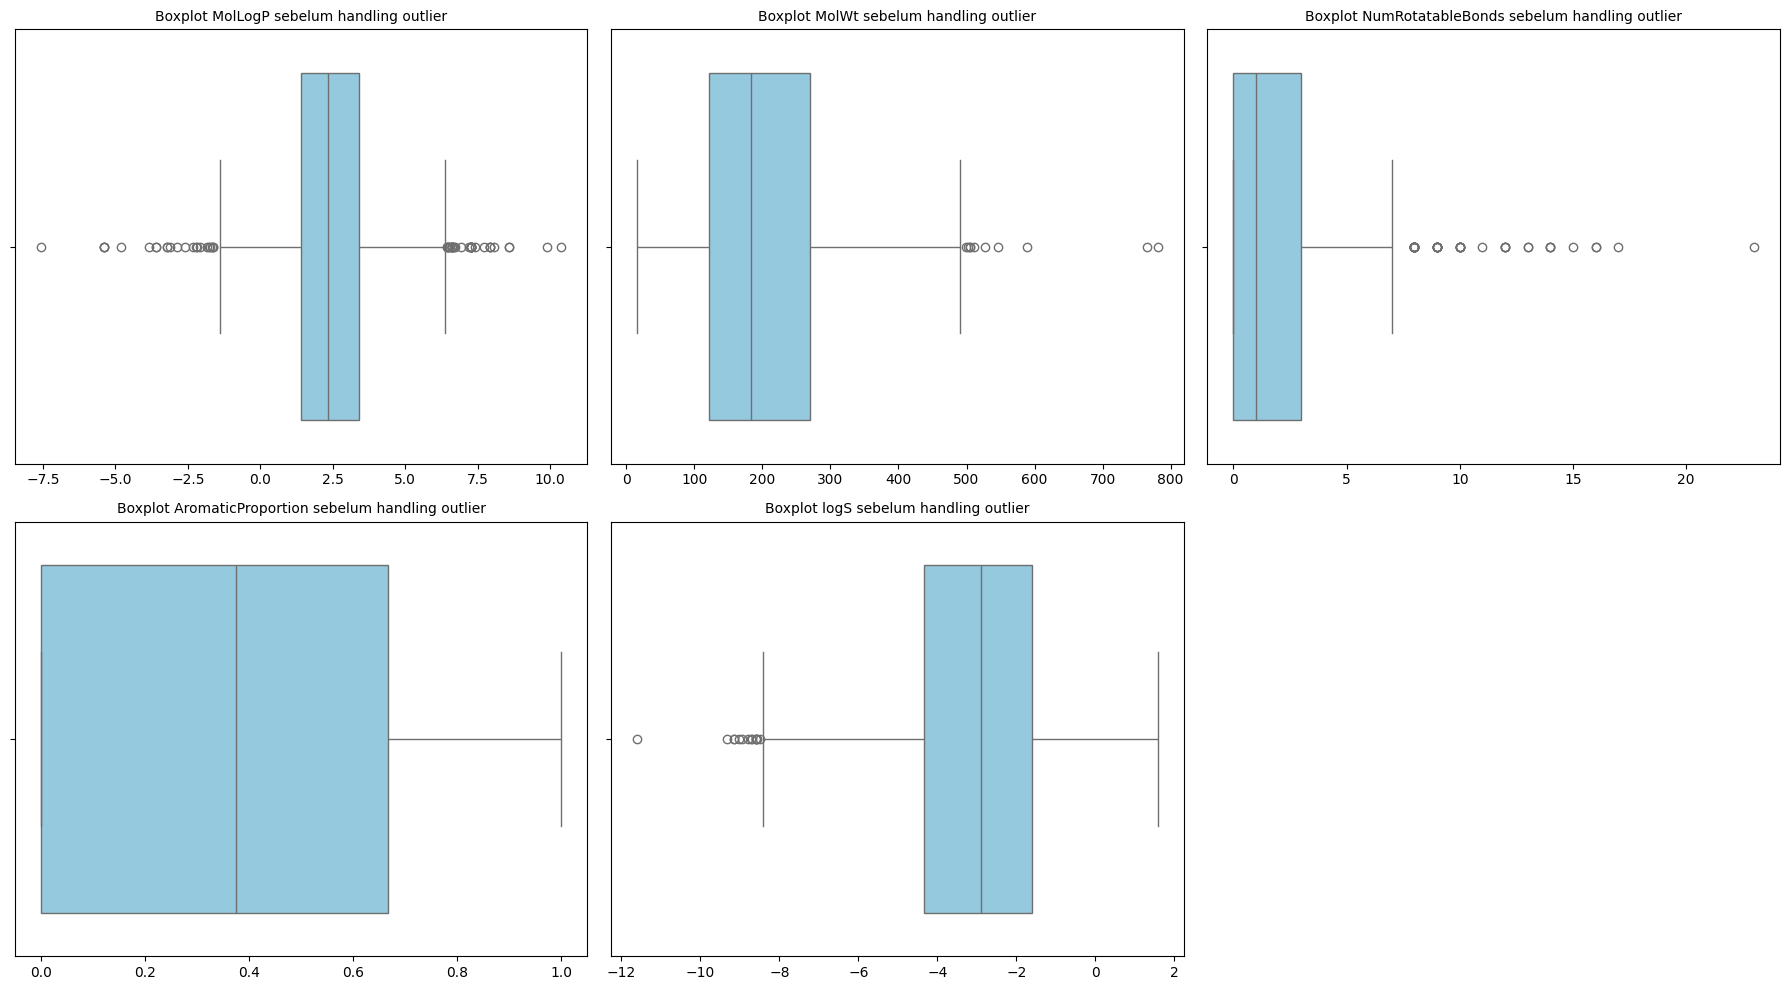

In [ ]:
fig, axes = plt.subplots(nrows= 2, ncols=3, figsize=(18, 10))
axes = axes.flatten()
for index, col in enumerate(list_data):
  sns.boxplot(x=df_raw[col], ax=axes[index], color='skyblue')
  axes[index].set_title(f'Boxplot {col} sebelum handling outlier', fontsize=10)
  axes[index].set_xlabel('')
axes[5].set_visible(False)
plt.tight_layout()
plt.show

Dari data di atas ditunjukkan kalau terdapat outlier pada kolom MolLogP, MolWt, NumRotatableBonds, dan LogS. Oleh karena itu, data tersebut perlu dihandling outliernya. Cara menghandlingnya adalah dengan Capping yakni dengan mengubah outlier atas menjadi batas atas data dan outlier bawah menjadi batas bawah. Hal ini bertujuan agar data tidak kehilangan karakter/nilai aslinya dibandingkan dengan imputasi menggunakan nilai median.

#### Capping Outlier

In [ ]:
df_cleaned = df_data.copy()
for col in list_data:
  Q1 = df_cleaned[col].quantile(0.25)
  Q3 = df_cleaned[col].quantile(0.75)
  IQR = Q3 - Q1
  batas_bawah = Q1 - 1.5 * IQR
  batas_atas = Q3 + 1.5 * IQR
  df_cleaned[col] = np.clip(df_cleaned[col], batas_bawah, batas_atas)

In [ ]:
jumlah_outlier_bawah = df_cleaned[col] < batas_bawah
jumlah_outlier_atas = df_cleaned[col] > batas_atas
print(f"Jumlah Outlier Min (Bawah): {jumlah_outlier_bawah.sum()}")
print(f"Jumlah Outlier Max (Atas) : {jumlah_outlier_atas.sum()}")

Jumlah Outlier Min (Bawah): 0
Jumlah Outlier Max (Atas) : 0


<function matplotlib.pyplot.show(close=None, block=None)>

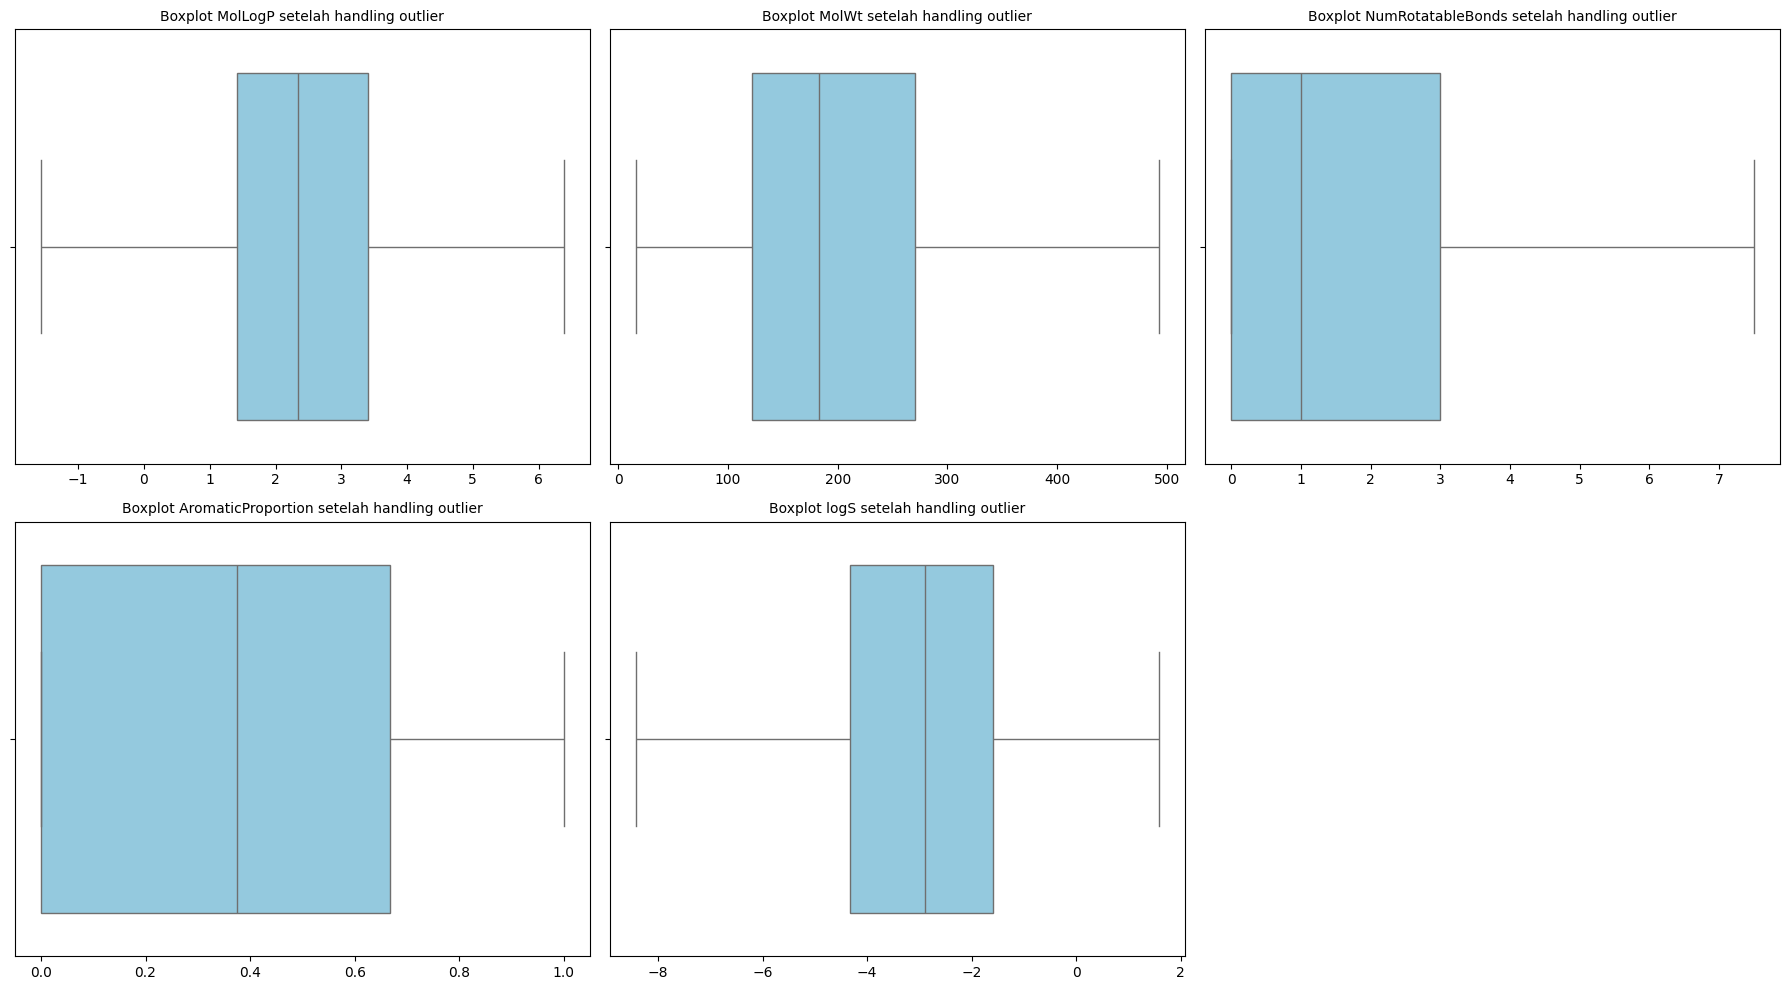

In [ ]:
list_data = ['MolLogP', 'MolWt', 'NumRotatableBonds', 'AromaticProportion', 'logS']
fig, axes = plt.subplots(nrows= 2, ncols=3, figsize=(18, 10))
axes = axes.flatten()
for index, col in enumerate(list_data):
  sns.boxplot(x=df_cleaned[col], ax=axes[index], color='skyblue')
  axes[index].set_title(f'Boxplot {col} setelah handling outlier', fontsize=10)
  axes[index].set_xlabel('')
axes[5].set_visible(False)
plt.tight_layout()
plt.show

###### Ini merupakan rekomendasi perbaikan antara data_raw dan data_cleaned untuk data yang belum dihandling outlier dan setelah dihandling

Berdasarkan hasil handling outlier, sudah tidak ditemukan adanya outlier pada data yang akan diuji. Jadi dataframe (df_cleaned) akan digunakan untuk proses/tahapan berikutnya. Tahapan selanjutnya adalah mengecek korelasi antara fitur dengan target.

### Check Korelasi dan Lineritas Data

#### Korelasi Data

In [ ]:
X = df_cleaned.drop('logS',axis=1)
y = df_cleaned['logS']

In [ ]:
df_cleaned[list_data].corr(method='pearson')

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
MolLogP,1.000000,0.518398,0.165752,0.254708,-0.846906
MolWt,0.518398,1.000000,0.406180,0.109212,-0.646808
NumRotatableBonds,0.165752,0.406180,1.000000,-0.309260,-0.197969
AromaticProportion,0.254708,0.109212,-0.309260,1.000000,-0.273151
logS,-0.846906,-0.646808,-0.197969,-0.273151,1.000000


In [ ]:
df_cleaned[list_data].corr(method='spearman')

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
MolLogP,1.000000,0.541487,0.103749,0.258283,-0.845771
MolWt,0.541487,1.000000,0.353876,0.167515,-0.673564
NumRotatableBonds,0.103749,0.353876,1.000000,-0.328669,-0.169031
AromaticProportion,0.258283,0.167515,-0.328669,1.000000,-0.253194
logS,-0.845771,-0.673564,-0.169031,-0.253194,1.000000


Tujuan korelasi ini untuk melihat korelasi dari fitur dan tabel yang tersedia pada data. Korelasi yang digunakan adalah korelasi Spearman dan Pearson. Meskipun data sudah dilakukan Capping sehingga outlier telah di handle, namun penggunaan Spearman lebih digunakan karena merepresentasikan hubungan yang lebih asli, yakni hubungan logaritmik. Hubungan antara x dan y tidak selamanya garis tegak lurus (linear) seperti Pearson.

#### Cek Linearitas Fitur dengan Target

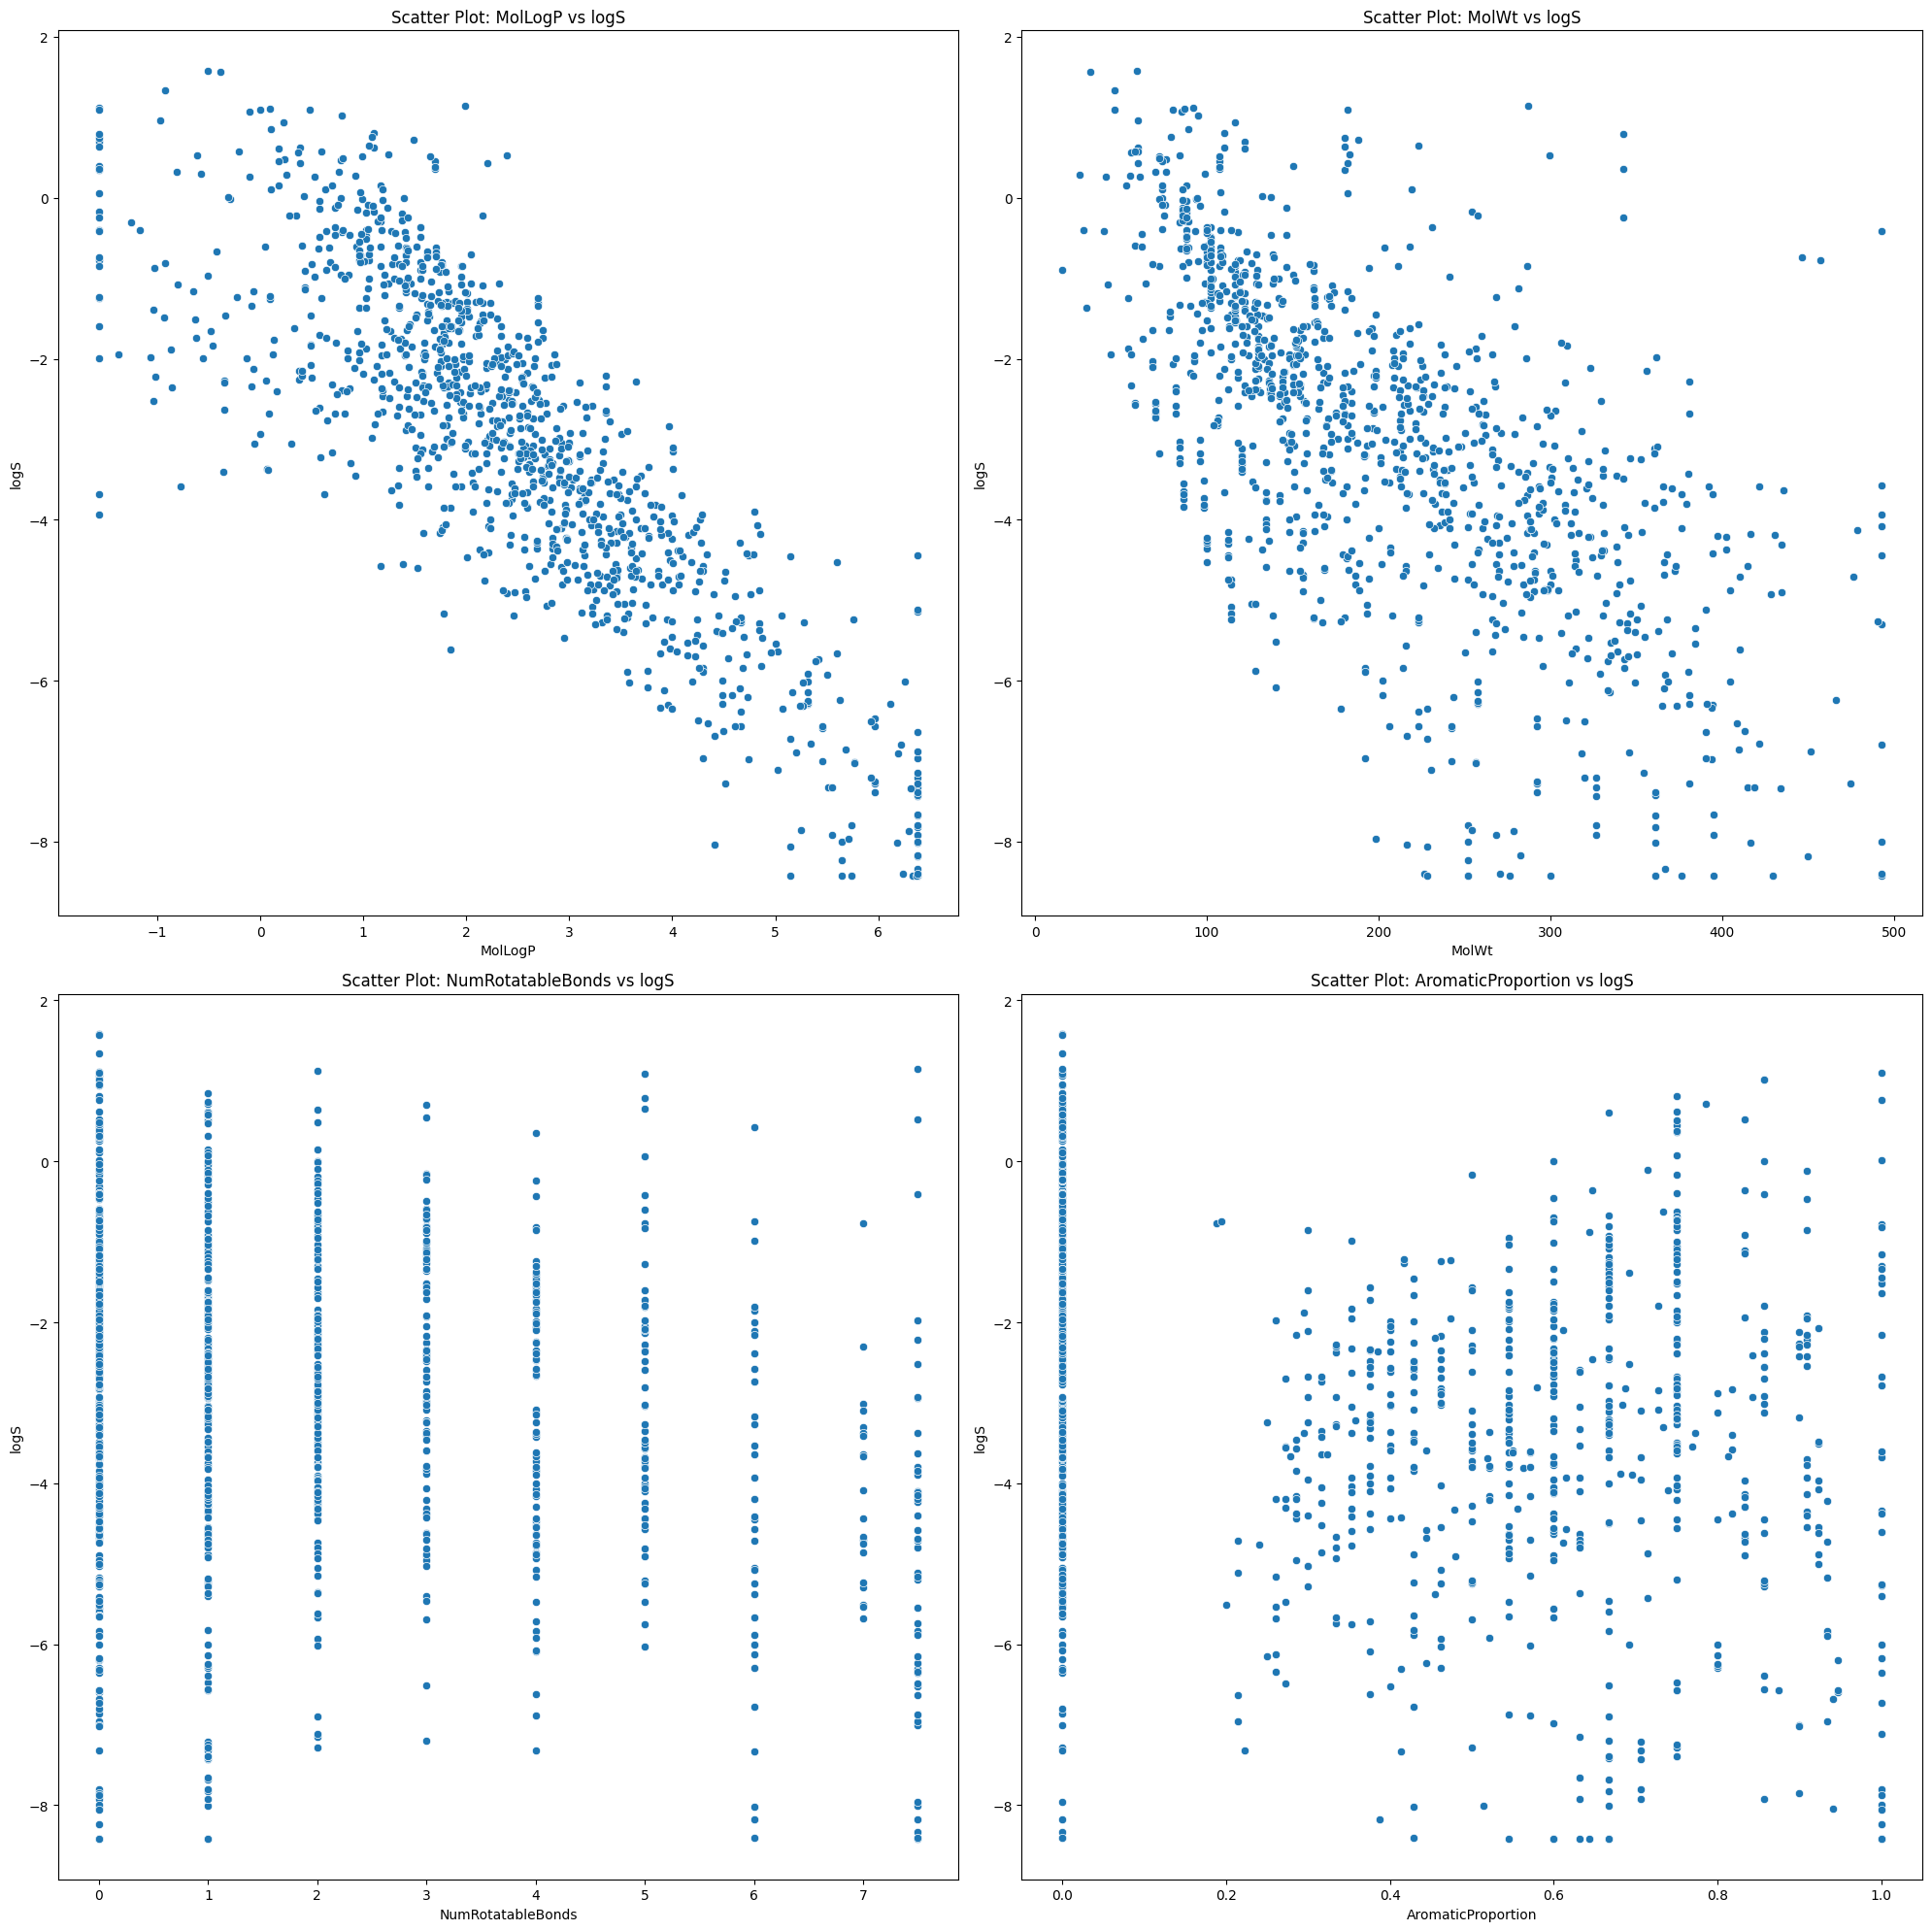

In [ ]:
fatures = X.columns
n_features = len(fatures)
n_cols = 2 # Definisikan grafik berdasarkan urutan kolom

# Hitung jumlah baris yang dibutuhkan berdasarkan jumlah fitur dan jumlah kolom
n_rows = np.ceil(n_features/n_cols).astype(int)
# Buat figure dan grid subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 20))
axes = axes.flatten()

#Looping untuk setiap fitur selain target
for i, feature in enumerate(fatures):
  ax = axes[i]
  sns.scatterplot(x=df_cleaned[feature], y=y, ax=ax)
  ax.set_title(f'Scatter Plot: {feature} vs logS')
  ax.set_xlabel(feature)
  ax.set_ylabel('logS')


for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

(a). Grafik MolLogP dengan logS menunjukkan bentuk pola diagonal yang jelas dan menurun ke bawah dari kiri ke kanan. Hal ini menunjukkan semakin besar Molecular LogP (MolLogP) (mudah terikat dengan minyak) maka semakin sulit untuk larut dalam air. Keadaan tersebut menunjukkan bahwa Mollecular LogP berkorelasi secara negatif dengan LogS dengan nilai korelasi spearman -0.845

(b). Grafik MolWt (berat molekul) dengan logS menunjukkan bentuk pola lebih melebar dan melengkung. Hubungannya tidak linear sempurna. Hal ini menunjukkan semakin besar MolWt (semakin besar berat molekul) maka semakin sulit untuk larut dalam air.  Keadaan tersebut menunjukkan bahwa MolWt berkorelasi secara negatif dengan LogS dengan nilai korelasi spearman -0.673.

(c). Grafik NumRotatableBonds (jumlah ikatan yang dapat berpitar) dengan logS menunjukkan hubungan negatif dan sangat lemah yang bernilai -0.169 pada korelasi spearman. Molekul yang memiliki ikatan yang lentur lebih mudah untuk berada di antara molekul air, tapi kelenturannya tidak berpengaruh jika ukuran fisiknya (MolWt) sudah terlanjur besar.

(d). Grafik AromaticProportion (Proporsi Aromatik) dengan logS menunjukkan hubungan negatif sangat lemah yakni -0.253 pada korelasi spearman. AromaticProportion ini mengukur persentase bagian molekul yang ditutupi oleh cincin ini sehingga air kesulitan untuk memisahkan molekul tersebut.

#### Check linearitas hubungan antar Fitur Numerik

##### Ini merupakan rekomendasi perbaikan yang disarankan, yakni mengeksplorasi dengan melihat hubungan antar fitur (variabel) dengan bantuan grafik pairplot, tidak hanya fitur dengan target.

<Figure size 2000x1800 with 0 Axes>

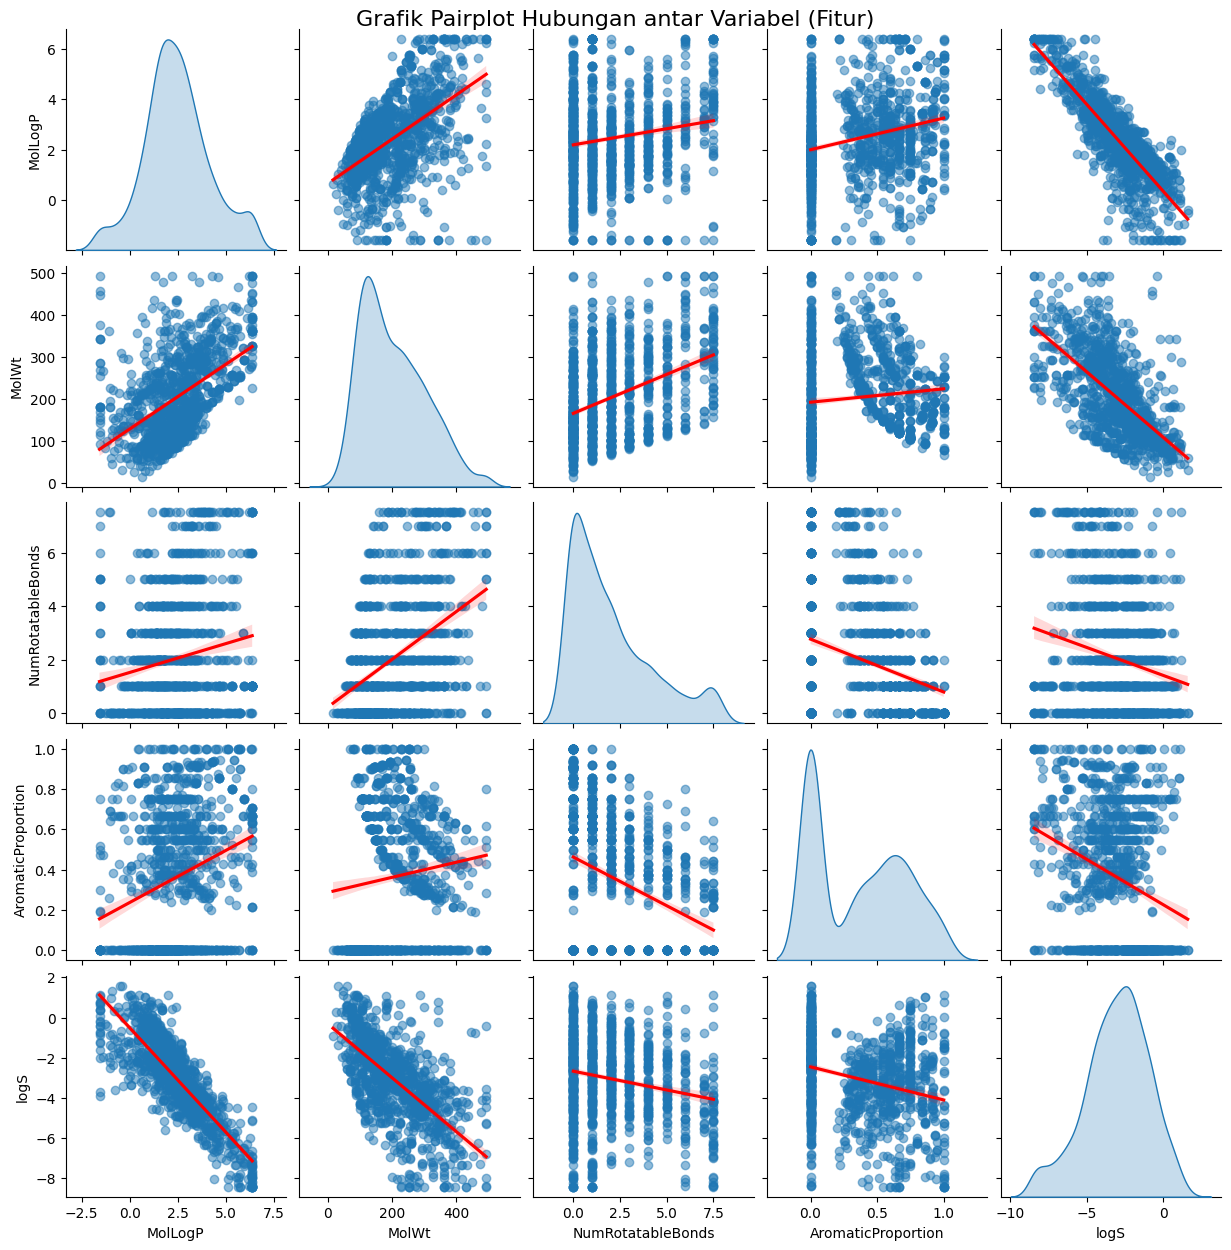

In [ ]:
plt.figure(figsize=(20,18))
sns.pairplot(df_cleaned, diag_kind='kde',kind='reg',plot_kws={'line_kws':{'color':'red'}, 'scatter_kws':{'alpha':0.5}})
plt.suptitle('Grafik Pairplot Hubungan antar Variabel (Fitur)', y=1, fontsize=16)
plt.show()

Dari penggambaran grafik pairplot ini, setidaknya ada 2 hal yang penting yang perlu diperhatikan. Adapun hal tersebut di antaranya:

(a). Grafik MolWt (berat molekul) dan NumRotatableBonds (jumlah ikatan yang dapat berputar) yang menunjukkan korelasi positif. Hal ini menunjukan semakin berat molekul kimianya, maka jumlah ikatan yang dapat berputar bebas akan semakin banyak.

(b). Grafik MolLogP (kecendrungan untuk berikatan dengan minyak) dan MolWt (berat molekul) yang menunjukan korelasi positif. Hal ini menunjukkan semakin berat molekulnya maka kecendrungan untuk bersifat hidrofobik akan semakin meningkat.

Dari grafik tersebut, terlihat bahwa kemungkinan terjadi multikolonieritas, sehingga perlu diidentifikasi menggunakan nilai Variance Inflation Factor (VIF)


### Menentukan Nilai VIF dan Melihat Multikolonieritas

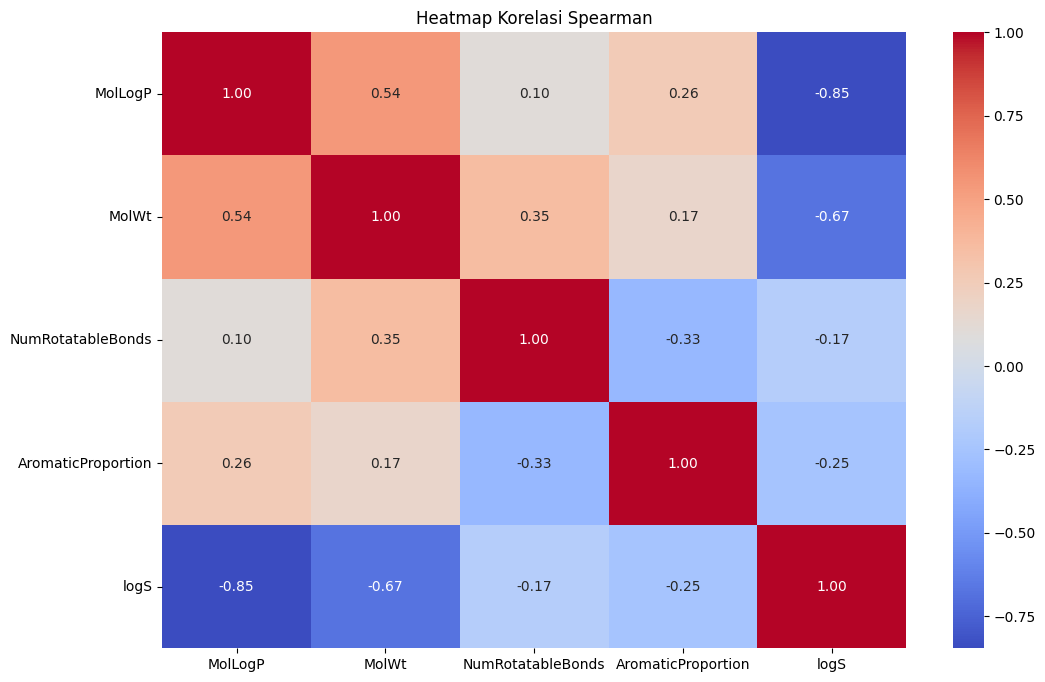

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_cleaned[['MolLogP','MolWt','NumRotatableBonds','AromaticProportion','logS']].corr(method='spearman'),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
)
plt.title('Heatmap Korelasi Spearman')
plt.show()

In [ ]:
def calc_vif(X):
  vif = pd.DataFrame()
  vif['Variables']= X.columns
  vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
  return vif

In [ ]:
calc_vif(X).sort_values(by='VIF', ascending=False)


,Variables,VIF
1,MolWt,6.412105
0,MolLogP,4.468853
2,NumRotatableBonds,2.557416
3,AromaticProportion,2.338621


Berdasarkan hasil perhitungan, nilai VIF pada masing-masing fitur berada di bawah 10, sehingga menunjukkan masing-masing fitur masih membawa informasi unik yang tidak dimiliki oleh fitur lainnya. Fitur MolWt masih memiliki korelasi negatif yang kuat terhadap MolLogP (r=-0.54) sehingga fitur ini tetap diperhatikan. Salah satu cara yang dilakukan adalah dengan menggunakan teknik regularisasi saat pemodelan machine learning.

### Splitting Data

In [ ]:
y = df_cleaned['logS']
X = df_cleaned.drop('logS', axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print('Train size: ', X_train.shape, y_train.shape)
print('Test size: ', X_test.shape, y_test.shape)

Train size:  (790, 4) (790,)
Test size:  (339, 4) (339,)


Kolom yang dijadikan y (target) adalah LogS (tingkat_kelarutan) sedangkan untuk fitur adalah data (MolLogP, MolWt, NumRotatableBonds, dan AromaticProportion). Persentase untuk train_size yakni sebesar 0.7 (70%)dari data yang tersedia atau 790 data. Untuk test_size persentasenya sebesar 0.3 (30%) dengan jumlah data sebesar 339. Jika data test terlalu kecil (5% atau 10%) maka akurasi dari test akan sensitif terhadap perubahan kecil. Persentase 30% memasitkan bahwa nilai evaluasi yang keluar dapat menjelaskan kemampuan model yang sesungguhnya.

#### Feature Scalling

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
X_train_scaled.head()

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
0,0.566996,-0.260767,0.429645,1.427152
1,0.264755,1.130501,1.351354,-0.289172
2,-0.902317,-1.454760,-0.952919,-1.090122
3,-0.406770,-0.849897,-0.492064,-1.090122
4,-0.081641,1.948104,0.429645,-1.090122


Menskalakan data fitur bertujuan agar pembelajaran machine learning berjalan dengan baik, karena komputer lebih terpengaruh terhadap angka yang lebih besar. Metode scalling yang digunakan adalah metode StandardScaler, karena data telah dibersihkan outliernya, sehingga standard scaler sebagai default dalam Scalling sudah sangat cukup.

## Pemilihan Metode Machine Learning (Revisi)

### Multiple Linear Regression

#### Penjelasan
Dalam pemilihan model, model yang digunakan adalah model multiple linear regression. Hal ini didasarkan karena terdapat lebih dari satu fitur (variabel) dan ingin mengetahui pengaruh fitur terhadap target.

In [ ]:
from sklearn.linear_model import LinearRegression
model_regresi = LinearRegression()
model_regresi.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred_train = model_regresi.predict(X_train_scaled)
y_pred_test = model_regresi.predict(X_test_scaled)

#### Evaluasi Model Machine Learning Linear Regression

In [ ]:
R2_train = r2_score(y_train, y_pred_train)
MAE_train = mean_absolute_error(y_train, y_pred_train)
MSE_train = mean_squared_error(y_train, y_pred_train)
RMSE_train = np.sqrt(MSE_train)
print(f"R2 Score Train: {R2_train:.3f}")
print(f"MAE Train : {MAE_train:.3f}")
print(f"MSE Train: {MSE_train:.3f}")
print(f"RMSE Train: {RMSE_train:.3f}")

R2 Score Train: 0.782
MAE Train : 0.758
MSE Train: 0.979
RMSE Train: 0.989


In [ ]:
R2_test = r2_score(y_test, y_pred_test)
MAE_test = mean_absolute_error(y_test,y_pred_test)
MSE_test = mean_squared_error(y_test,y_pred_test)
RMSE_test = np.sqrt(MSE_test)
print(f"R2 Score Test: {R2_test:.3f}")
print(f"MAE Test : {MAE_test:.3f}")
print(f"MSE Test: {MSE_test:.3f}")
print(f"RMSE Test: {RMSE_test:.3f}")

R2 Score Test: 0.775
MAE Test : 0.717
MSE Test: 0.846
RMSE Test: 0.920


In [ ]:
hasil_linear_regresi = pd.DataFrame([["Linear Regression", MAE_train, MAE_test, MSE_train, MSE_test, RMSE_train, RMSE_test, R2_train, R2_test]],
                                    columns=['Model', 'MAE_train', 'MAE_test', 'MSE_train', 'MSE_test', 'RMSE_train', 'RMSE_test', 'R2_train', 'R2_test'])
hasil_linear_regresi

,Model,MAE_train,MAE_test,MSE_train,MSE_test,RMSE_train,RMSE_test,R2_train,R2_test
0,Linear Regression,0.758485,0.717235,0.978789,0.845575,0.989338,0.919551,0.782269,0.774597


#### Hasil Evaluasi Line Regression

(a). MAE menunjukkan besaran kesalahan prediksi dengan nilai sebernarnya. Nilai MAE_train adalah 0.758 dan MAE_test sebesar 0.717. Semakin kecil nilai MAE, semakin bagus karena nilai eror.

(b). MSE menunjukkan rata-rata selisih kuadrat dari nilai prediksi dengan nilai sebenarnya. Nilai MSE_Train 0.978 dan MSE_Test 0.845. Semakin kecil semakin bagus nilainya.

(c). Dari hasil pembuatan model traditional Machine Learning, nilai R2 score train sebesar = 0.782 dan R2 score test = 0.774 yang menunjukkan bahwa model dalam keadaan good fit. Hal ini disebebkan nilai R2 berada dalam rentang yang tidak terlalu jauh (tidak signifikan).

(d). RSME merupakan metrik yang digunakan untuk mengukur seberapa jauh jarak rata-rata antara tebakan model machine learning dengan nilai yang sebenernya. Semakin mendekati 0 semakin bagus nilai RSMEnya. Nilai RSME_train sebesar 0.989 dan RSME_test sebesar 0.919

### Ridge Regression

#### ini merupakan saran perbaikan sebelumnya.

#### Penjelasan

Seperti yang telah dilihat pada bagian nilai VIF, ditemukan beberapa fitur yang memiliki nilai VIF yang moderat (di atas 5) yakni pada MolWt dengan VIF samadengan 6.41. Jika mmenggunakan model linear regression biasa akan menyebabkan model matematika mengalami overfitting akibat adanya perubahan pada data training.

Dengan menggunakan Ridge Regression akan mengecilkan nilai koefisien hingga mendekati 0 untuk fitur yang memiliki korelasi rendah dan mempertahankan model tanpa merusak kestabilan model matematikanya.

In [ ]:
from sklearn.linear_model import Ridge
parameter_grid = {'alpha':[0.001,0.01,0.1,1.0,10.0,100.0]}
ridge_model = Ridge()

Ridge Regression memiliki parameter alpha (α) yang berfungsi untuk mengontrol kekuatan regularisasi. Semakin besar nilai Alpha yang diterapkan, maka akan menghasilkan regularisasi yang lebih kuat.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
random_search_ridge = RandomizedSearchCV(ridge_model, parameter_grid, n_iter=5, scoring='r2', cv=5, random_state=42)
random_search_ridge.fit(X_train_scaled, y_train)
print(f"Alpha terbaik: {random_search_ridge.best_params_['alpha']:.2f}")

Alpha terbaik: 0.10


Untuk model ridge regression, pencarian nilai alpha menggunakan RandomizedSearchCV untuk alternatif optimasi dengan mencari nilai alpha terbaik secara acak dari distribusi kontinu dalam rentang tertentu. Pendekatan ini lebih efektif karena tidak membutuhkan waktu komputasi yang terlalu lama.

In [ ]:
y_pred_train = random_search_ridge.predict(X_train_scaled)
y_pred_test = random_search_ridge.predict(X_test_scaled)

#### Evaluasi Model Ridge Regression

In [ ]:
R2_train_ridge = r2_score(y_train, y_pred_train)
MAE_train_ridge = mean_absolute_error(y_train, y_pred_train)
MSE_train_ridge = mean_squared_error(y_train, y_pred_train)
RMSE_train_ridge = np.sqrt(MSE_train_ridge)

print(f"R2 Score Train: {R2_train_ridge:.3f}")
print(f"MAE Train : {MAE_train_ridge:.3f}")
print(f"MSE Train: {MSE_train_ridge:.3f}")
print(f"RMSE Train: {RMSE_train_ridge:.3f}")

R2 Score Train: 0.782
MAE Train : 0.758
MSE Train: 0.979
RMSE Train: 0.989


In [ ]:
R2_test_ridge = r2_score(y_test, y_pred_test)
MAE_test_ridge = mean_absolute_error(y_test, y_pred_test)
MSE_test_ridge = mean_squared_error(y_test, y_pred_test)
RMSE_test_ridge = np.sqrt(MSE_test_ridge)

print(f"R2 Score Test: {R2_test_ridge:.3f}")
print(f"MAE Test : {MAE_test_ridge:.3f}")
print(f"MSE Test: {MSE_test_ridge:.3f}")
print(f"RMSE Test: {RMSE_test_ridge:.3f}")

R2 Score Test: 0.775
MAE Test : 0.717
MSE Test: 0.846
RMSE Test: 0.920


In [ ]:
hasil_ridge_regresi = pd.DataFrame([["Ridge Regression", MAE_train_ridge, MAE_test_ridge, MSE_train_ridge, MSE_test_ridge, RMSE_train_ridge, RMSE_test_ridge, R2_train_ridge, R2_test_ridge]],
                                    columns=['Model', 'MAE_train_ridge', 'MAE_test_ridge', 'MSE_train_ridge', 'MSE_test_ridge', 'RMSE_train_ridge', 'RMSE_test_ridge', 'R2_train_ridge', 'R2_test_ridge'])
hasil_ridge_regresi

,Model,MAE_train_ridge,MAE_test_ridge,MSE_train_ridge,MSE_test_ridge,RMSE_train_ridge,RMSE_test_ridge,R2_train_ridge,R2_test_ridge
0,Ridge Regression,0.758492,0.717235,0.978789,0.845569,0.989338,0.919548,0.782269,0.774599


### Perbandingan Linear Regression dan Ridge Regression

In [ ]:
df_linear = pd.DataFrame([["Linear Regression", MAE_train, MAE_test, MSE_train, MSE_test, RMSE_train, RMSE_test, R2_train, R2_test]],
                         columns=['Model', 'MAE_train', 'MAE_test', 'MSE_train', 'MSE_test', 'RMSE_train', 'RMSE_test', 'R2_train', 'R2_test'])

df_ridge = pd.DataFrame([["Ridge Regression", MAE_train_ridge, MAE_test_ridge, MSE_train_ridge, MSE_test_ridge, RMSE_train_ridge, RMSE_test_ridge, R2_train_ridge, R2_test_ridge]],
                        columns=['Model', 'MAE_train', 'MAE_test', 'MSE_train', 'MSE_test', 'RMSE_train', 'RMSE_test', 'R2_train', 'R2_test'])

df_models = pd.concat([df_linear, df_ridge], axis=0).reset_index(drop=True)

df_models

,Model,MAE_train,MAE_test,MSE_train,MSE_test,RMSE_train,RMSE_test,R2_train,R2_test
0,Linear Regression,0.758485,0.717235,0.978789,0.845575,0.989338,0.919551,0.782269,0.774597
1,Ridge Regression,0.758492,0.717235,0.978789,0.845569,0.989338,0.919548,0.782269,0.774599


(a). Berdasarkan hasil evaluasi, Linear Regression dan Ridge Regression menunjukkan performa yang hampir sama. Linear Regression memperoleh nilai R² test sebesar 0,7746, sedangkan Ridge Regression memperoleh nilai R² test sebesar 0,7746 dengan selisih yang sangat kecil. Nilai selisih yang kecil juga terjadi pada parameter MAE, MSE, dan RMSE kedua model juga tidak menunjukkan perbedaan yang signifikan.

(b). Ridge Regression bertujuan untuk mengurangi overfitting melalui regularisasi. Namun, pada dataset ini tidak ditemukan indikasi overfitting yang berarti, yang terlihat dari nilai R² train dan R² test yang selisihnya tidak terlalu jauh. Selain itu, nilai alpha terbaik yang diperoleh dari metode random search hanya sebesar 0,1, menunjukkan bahwa kebutuhan regularisasi pada data cukup rendah.

Oleh karena itu, Linear Regression dipilih karena memberikan performa yang sedikit lebih baik dengan kompleksitas yang lebih sederhana dan lebih mudah untuk diinterpretasikan dipahami.

### Random Forest

#### Penjelasan

Pemilihan  Machine Learning untuk model kedua ini adalah Metode Random Forest. Alasan pemilihan metode Random Forest ini adalah jika terdapat kesalahan tebakan (bias) dari satu pohon akan dianulir oleh pohon lainnya saat memprediksi nilai LogS. Cara kerjanya adalah komputer akan membuat satu pohon kecil yang diberi data train secara acak (bootstraping). Setelah selesai belajar, model akan ditest (prediksi) dan tentunya akan memiliki variasi jawaban. Pada akhirnya prediksi dikumpulkan dan digabungkan (aggregating) semua jawaban tersebut.


Jika mengambil decision tree, data akan dibelah secara terus-menerus hingga sangat detail. Model akan cenderung lebih menghafal seluruh data train, hingga ke titik eror terkecilnya sehingga model akan cenderung mengalami overfitting.

Jika menggunakkan stacking, menggabungkan model dari beberapa jenis model (seperti menggabungkan Regresi Linear dan Random Forest) dan hasilnya digabungkan oleh model penentu (Meta-Regressor). Model akan terlalu kompleks sehingga terlalu berlebihan dan tidak efisien secara waktu komputasi.

In [ ]:
parameter_distribusion = {'n_estimators' : [int (x) for x in np.linspace(start=50, stop=300, num=6)],
                          'max_depth' : [5, 10, 15, 20, 25, None],
                          'min_samples_split' : [2, 5, 10],
                          'max_features' : ['sqrt', 'log2', None]}

Parameter distribution mendefinisikan pencarian hyperparameter. Hyperparamater merupakan aturan yang memberi tahu model bagaimana cara menemukan jawaban (prediksi). n_estimator menunjukkan jumlah pohon keputusan yang akan dihasilkan (dengan batas bawah 50 dan batas atas 300) dan membaginya menjadi 6 kelompok yang sama. Nilai max_depth dan min_sample_split merepresentasikan instrumen regularisasi untuk mengontrol kompleksitas geometri pohon keputusan, sehingga terhindar dari overfitting. Pembatasan fitur melalui sqrt atau log2 merupakan instrumen penting untuk menciptakan perbedaan dan model dapat memiliki kemampuan generalisasi yang tinggi dan ketahanan yang baik terhadap overfitting.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)
random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=parameter_distribusion, n_iter=10,cv=5,scoring='r2',random_state=42,n_jobs=-1)
random_search.fit(X_train_scaled, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 15, 20, 25, None],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 150, 200, 250,
                                                         300]},
                   random_state=42, scoring='r2')

Random search digunakan untuk melakukan proses Hyperparameter Tuning (optimasi model) secara otomatis dan efisien. Random search mengambil nilai berdasarkan sampel kombinasi nilai secara acak sebanyak jumlah iterasi (n_iter) yang ditentukan. Data train akan dibagi menjadi 5 bagian dan diuji secara bergantian di setiap potongan data tersebut.

In [ ]:
y_pred_train = random_search.predict(X_train_scaled)
y_pred_test = random_search.predict(X_test_scaled)

#### Evaluasi Model Random Forest

In [ ]:
def regressor_report(y_true, y_pred):
    R2_rf = r2_score(y_true, y_pred)
    MAE_rf = mean_absolute_error(y_true, y_pred)
    MSE_rf = mean_squared_error(y_true, y_pred)
    RMSE_rf = np.sqrt(MSE_rf)

    print(f'R2 Score: {R2_rf:.2f}')
    print(f'MAE: {MAE_rf:.2f}')
    print(f'MSE: {MSE_rf:.2f}')
    print(f'RMSE: {RMSE_rf:.2f}')

In [ ]:
print("Hasil Pengujian Training Set:")
print(regressor_report(y_train, y_pred_train))

print("\nHasil Pengujian Test Set:")
print(regressor_report(y_test, y_pred_test))

Hasil Pengujian Training Set:
R2 Score: 0.98
MAE: 0.22
MSE: 0.09
RMSE: 0.30
None

Hasil Pengujian Test Set:
R2 Score: 0.88
MAE: 0.50
MSE: 0.45
RMSE: 0.67
None


In [ ]:
R2_train_rf = r2_score(y_train, y_pred_train)
R2_test_rf = r2_score(y_test, y_pred_test)
MSE_train_rf = mean_squared_error(y_train, y_pred_train)
RMSE_train_rf = np.sqrt(MSE_train_rf)
MSE_test_rf = mean_squared_error(y_test, y_pred_test)
RMSE_test_rf = np.sqrt(MSE_test_rf)
MAE_train_rf = mean_absolute_error(y_train, y_pred_train)
MAE_test_rf = mean_absolute_error(y_test, y_pred_test)

hasil_random_forest = pd.DataFrame([["Random Forest",MAE_train_rf, MAE_test_rf, MSE_train_rf, MSE_test_rf, RMSE_train_rf, RMSE_test_rf, R2_train_rf, R2_test_rf]],
                                    columns=['Model','MAE_train_rf', 'MAE_test_rf', 'MSE_train_rf','MSE_test_rf', 'RMSE_train', 'RMSE_test', 'R2_train', 'R2_test'])
hasil_random_forest

,Model,MAE_train_rf,MAE_test_rf,MSE_train_rf,MSE_test_rf,RMSE_train,RMSE_test,R2_train,R2_test
0,Random Forest,0.216825,0.498428,0.087475,0.453703,0.295761,0.673575,0.980541,0.879057


Secara rata-rata, kesalahan tebakan kelarutan pada model Random Forest hanya meleset sebesar 0.498 (MAE_test_rf) dibandingkan dengan nilai sesungguhnya. Kemudian untuk standar deviasi kesalahan prediksi (RSME_test) adalah 0.673 dan lebih rendah dibandingkan dengan metode sebelumnya, sehingga membuktikan bahwa model ini berhasil mengurangi prediksi yang sangat jauh.

Dari hasil pembuatan model traditional Machine Learning, nilai R2 score train sebesar = 0.98 dan R2 score test = 0.87 yang menunjukkan bahwa model dalam keadaan overfit. Hal ini disebabkan nilai model cenderung lebih menghafal dan saat dilakukan test, nilai R2 menjadi lebih kecil.

### Perbandingan Linear Regression dan Random Forest

In [ ]:
df_linear = pd.DataFrame([["Linear Regression", MAE_train, MAE_test, MSE_train, MSE_test, RMSE_train, RMSE_test, R2_train, R2_test]],
                         columns=['Model', 'MAE_train', 'MAE_test', 'MSE_train', 'MSE_test', 'RMSE_train', 'RMSE_test', 'R2_train', 'R2_test'])

df_rf = pd.DataFrame([["Random Forest", MAE_train_rf, MAE_test_rf, MSE_train_rf, MSE_test_rf, RMSE_train_rf, RMSE_test_rf, R2_train_rf, R2_test_rf]],
                     columns=['Model', 'MAE_train', 'MAE_test', 'MSE_train', 'MSE_test', 'RMSE_train', 'RMSE_test', 'R2_train', 'R2_test'])

df_models = pd.concat([df_linear, df_rf], axis=0).reset_index(drop=True)
df_models

,Model,MAE_train,MAE_test,MSE_train,MSE_test,RMSE_train,RMSE_test,R2_train,R2_test
0,Linear Regression,0.758485,0.717235,0.978789,0.845575,0.989338,0.919551,0.782269,0.774597
1,Random Forest,0.216825,0.498428,0.087475,0.453703,0.295761,0.673575,0.980541,0.879057


#### Penjelasan dan Keputusan Pemilihan Metode Machine Learning

Random Forest memberikan hasil prediksi terbaik, namun Linear Regression menunjukkan hasil yang lebih stabil dengan tingkat overfitting yang lebih rendah.

Berdasarkan hasil evaluasi, Random Forest menghasilkan nilai R² Test yang lebih tinggi dibandingkan Linear Regression, yaitu sebesar 0,879 dibandingkan 0,775. Namun, Random Forest juga menunjukkan selisih yang cukup besar antara nilai R² Train (0,981) dan R² Test (0,879), yang mengindikasikan adanya kecenderungan overfitting. Sebaliknya, Linear Regression memiliki nilai R² Train dan R² Test yang sangat berdekatan, yaitu 0,782 dan 0,775, sehingga menunjukkan kemampuan prediksi yang lebih baik dan kondisi model yang lebih stabil (good fit).

Oleh karena itu, meskipun Random Forest memiliki akurasi yang lebih tinggi pada data pengujian, Linear Regression dinilai lebih baik dalam merepresentasikan pola data secara umum karena menghasilkan model yang lebih sederhana, stabil, dan tidak menunjukkan indikasi overfitting yang signifikan.

# Mini Project II

## Penjelasan

Dalam Mini Project II ini, Data Preprocessing dan Feature Engineering (Handling outlier, feature scalling) telah dilakukan pada bagian sebelumnya termasuk dengan saran rekomendasi perbaikan yang dikirimkan di email. Pengerjaan ini dikerjakan pada file yang berbeda, namun dengan konsep yang sama dan beberapa pembaharuan.

Harapan (personal) dari pengerjaan Mini Project II ini adalah mampu memahami fundamental dari ANN kemudian mampu memahami perbedaan antara ML yang dirancang pada Mini Project I serta mampu mendeploy melalui streamlit.

## Artificial Neuron Network

### Splitting Data Proportion

In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,y, test_size=0.15, random_state = 42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.15, random_state=42
)

print(f"Train size: ",X_train.shape)
print(f"Validation size : ",X_val.shape)
print(f"Test size : ",X_test.shape)

Train size:  (815, 4)
Validation size :  (144, 4)
Test size :  (170, 4)


Jika sebelumnya pada machine learning, data hanya dibagi menjadi train set dan test set, maka pada ANN ini terdapat validation set yang berfungsi untuk melakukan pengujian model pada tahap awal (try out). Data untuk test-set 170 data dengan persentase (0.15%). Persentase menurun karena jika menggunakan persentase yang sama dengan Model ML, akan menyebabkan data latihan terlalu sedikit, sehingga dikhawatirkan akan terjadi underfit.

Adapun jumlah data pada data training set adalah 815 dengan jumlah data untuk validation set adalah 170 data.

### Arsitektur Model

In [ ]:
seed = 20
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

# Melihat Versi
print(tf.__version__)
print(tf.keras.__version__)

2.20.0
3.13.2


Kode di atas berfungsi untuk membangun model ANN dengan TensorFlow/Keras agar diperoleh hasil training yang lebih baik dan versi library yang digunakan.

In [ ]:
model = Sequential()

model = Sequential([
    Input(shape=(4,), name='input-layer'),

    Dense(
        8, activation='relu',
        kernel_initializer=HeNormal(seed=seed),
        name='hidden-layer-1'
    ),

    Dropout(0.1),

    Dense(
        4, activation='relu',
        kernel_initializer=HeNormal(seed=seed),
        name='hidden-layer-2'
    ),

    Dense (1,
        kernel_initializer=HeNormal(seed=seed),
        name='output-layer'
    )

])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden-layer-1 (Dense)          │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden-layer-2 (Dense)          │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output-layer (Dense)            │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

Model yang digunakan dalam ANN adalah sequential() di mana input shape tidak terlihat secara eksplisit. Jumlah neuron 8 pada hidden layer 1 dan  4 pada hidden layer 2 disebabkan disesuaikan dengan input yang ada. Jika terlalu banyak neuron dikhawatirkan akan menyebabkan model menjadi

Activation function yang dipilih adalah ReLU prinsp yang sederhana (bilangan negatif menjadi 0 dan positif menjadi bilangan itu sendiri) sehingga proses training ANN akan berjalan dengan cepat. Dipasangkan dengan HeNormal karena memastikan skala nilai awal bobot tidak kekecilan dan tidak terlalu besar, sehingga sebagian besar neuron ReLU langsung berada di area aktif (area positif) ketika epoch pertama dimulai.

Adanya Droput pada arsitektur model dipilh karena agar model tidak overfitting sehingga model ANN tidak hanya menghafal. Angka 0.1 dipilih untuk droput karena
hanya punya 4 neuron, secara statistik sistem akan menonaktifkan sekitar 1 neuron secara bergantian di setiap langkah.

### Model Compiied

In [ ]:
model.compile(
    loss='mse',
    optimizer=Adam(learning_rate=0.001),
    metrics=['mae',tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)

Kode diatas adalah kode untuk mrnyiapkan model agar siap dilatih. Adam berfungsi untuk memperbaharui dan memperbaiki bobot yang ada di dalam model berdasarkan hasil loss function, agar iterasi kesalahan model menjadi lebih kecil. MSE digunakan sebagai media ukur kesalahannya saat belajar, dan MAE adalah indikator performa yang akan dipantau.

### Training Model

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
model_checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True
)

In [ ]:
print("Ukuran X_train_scaled:", X_train_scaled.shape)
print("Ukuran y_train:", y_train.shape)

Ukuran X_train_scaled: (790, 4)
Ukuran y_train: (815,)


In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop,model_checkpoint])

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 10.6050 - mae: 2.6318 - rmse: 3.2565 - val_loss: 8.2662 - val_mae: 2.2225 - val_rmse: 2.8751
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.5734 - mae: 2.3686 - rmse: 2.9280 - val_loss: 6.5114 - val_mae: 1.9492 - val_rmse: 2.5517
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.9718 - mae: 2.1351 - rmse: 2.6404 - val_loss: 5.3145 - val_mae: 1.7726 - val_rmse: 2.3053
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.8530 - mae: 1.9627 - rmse: 2.4193 - val_loss: 4.4553 - val_mae: 1.6327 - val_rmse: 2.1108
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.8818 - mae: 1.7942 - rmse: 2.2095 - val_loss: 3.7808 - val_mae: 1.5154 - val_rmse: 1.9444
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.3094 - mae: 1.6948 - rmse: 2.0759 - val_loss: 3.2441 - val_mae: 1.4136 - val_rmse: 1.8012
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.6628 - mae: 1.5523 - rmse: 1.913

Dalam training, jumlah epochs yang digunakan adalah 50 dengan batch_size = 32. Kemudian digunakan call backs early stopp karena tidak diketahui sebelumnya pada epoch ke berapa model akan mencapai performa terbaik, sedangkan model checkpoint berfungsi untuk memantau performa model selama proses training dan menyimpan versi terbaik. Oleh karena itu, jumlah epoch yang digunakan 100 agar model dapat berhenti secara otomatis ketika performa sudah tidak meningkat lagi.

### Evaluasi Model

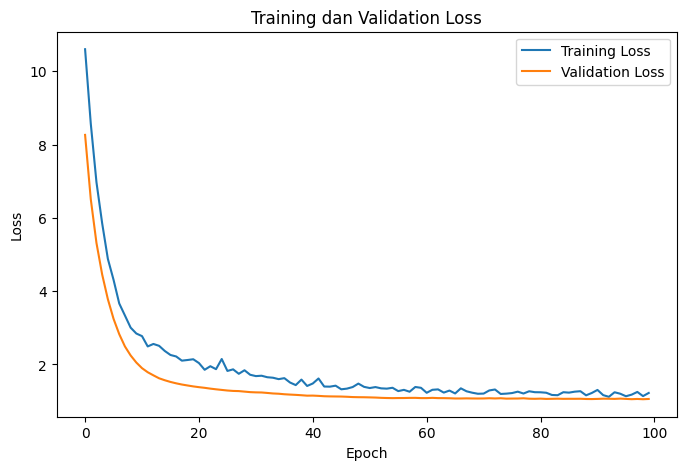

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training dan Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Grafik merepresentasikan keadaan goodfit, garis antara training loss dan validation loss berjalan dan konsisten turun. Model tidak hanya menghafal data latihan, tetapi memahami polanya sehingga dapat melakukan prediksi untuk menebak data.

In [ ]:
def evaluasi_ANN_Model(model, X_data, y_data, data_name):
  y_pred = model.predict(X_data)
  mae = mean_absolute_error(y_data, y_pred)
  mse = mean_squared_error(y_data, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_data, y_pred)

  print(f"-------- {data_name} --------")
  print(f"MAE: {mae:.3f}")
  print(f"MSE: {mse:.3f}")
  print(f"RMSE: {rmse:.3f}")
  print(f"R2 : {r2:.3f}")
  return r2, mae, mse, rmse

In [ ]:
# Evaluasi training data
evaluasi_ANN_Model(model, X_train_scaled, y_train, "Data Training ANN")
R2_train_ann, MAE_train_ann, MSE_train_ann, RMSE_train_ann = None, None, None, None

# Evaluasi validation data
evaluasi_ANN_Model(model, X_val_scaled, y_val, "Data Validasi ANN")

# Evaluasi test data
evaluasi_ANN_Model(model, X_test_scaled, y_test, "Data Test ANN")
R2_test_ann, MAE_test_ann, MSE_test_ann, RMSE_test_ann = None, None, None, None

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
-------- Data Training ANN --------
MAE: 0.773
MSE: 0.967
RMSE: 0.983
R2 : 0.778
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
-------- Data Validasi ANN --------
MAE: 0.805
MSE: 1.049
RMSE: 1.024
R2 : 0.755
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
-------- Data Test ANN --------
MAE: 0.745
MSE: 0.871
RMSE: 0.933
R2 : 0.777


Dari hasil eror data, model berjalan secara goodfit. Jika dilihat dari nilai R2 saat training adalah 0.770. Namun saat dilakukan validation test nilai r2 adalah 0.750. Saat dilakukan ujian yang sebenarnya (test) nilainya meningkat kembali menjadi 0.769. Rentang nilai yang tidak berbeda terlalu jauh menunjukkan model berjalan secara goodfit.

### Evaluasi Model Machine Learning (Linear Regression) dengan Model ANN.

In [ ]:
R2_test_ann, MAE_test_ann, MSE_test_ann, RMSE_test_ann = evaluasi_ANN_Model(
    model, X_test_scaled, y_test, "Data Test ANN"
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
-------- Data Test ANN --------
MAE: 0.745
MSE: 0.871
RMSE: 0.933
R2 : 0.777


In [ ]:
df_perbandingan_test = pd.DataFrame({
    'Model': ['Linear Regression', 'ANN'],
    'MAE Test': [MAE_test, MAE_test_ann],
    'MSE Test': [MSE_test, MSE_test_ann],
    'RMSE Test': [RMSE_test, RMSE_test_ann],
    'R2 Test': [R2_test, R2_test_ann]
})

df_perbandingan_test

,Model,MAE Test,MSE Test,RMSE Test,R2 Test
0,Linear Regression,0.717235,0.845575,0.919551,0.774597
1,ANN,0.745310,0.870640,0.933081,0.777289


Berdasarkan hasil final dari tabel tersebut, Linear Regression lebih baik  dibandingkan ANN. Hal ini didasarkan pada:

(a). Nilai eror yang lebih kecil: Nilai MAE, MSE, dan RMSE milik Linear Regression semuanya lebih rendah daripada ANN. sebagai contoh, MAE Linear Regression hanya 0.717, sedangkan ANN meleset sebesar 0.761. Berarti tebakan Linear Regression lebih mendekati nilai asli.

(b). Akurasi polanya yang lebih tinggi: Nilai (R-Squared) Linear Regression sedikit lebih tinggi, yaitu 0.774 (77.4%), dibanding ANN yang berada di angka 0.768 (76.8%).

Hal ini dapat terjadi karena jumlah ukuran dataset yang ringkas, di mana model machine learning konvensional terbukti lebih baik dan akuran dibandingkan dengan model deep learning.



### Save Models

In [ ]:
import os
import joblib
import tensorflow as tf

# 1. Membuat folder khusus untuk menyimpan model jika belum ada
loc_model_save = "saved_models"
os.makedirs(loc_model_save, exist_ok=True)

joblib.dump(scaler, os.path.join(loc_model_save, "ml_scaler.joblib"))
joblib.dump(scaler, os.path.join(loc_model_save, "ann_scaler.joblib"))
print("Scaler berhasil disimpan!")

joblib.dump(model_regresi, os.path.join(loc_model_save, "linear_regression.joblib"))
print("Model Linear Regression berhasil disimpan!")

model.save(os.path.join(loc_model_save, "ann_model.keras"))
print("Model ANN (.keras) berhasil disimpan!")

model.save(os.path.join(loc_model_save, "ann_model.h5"))
print("Model ANN (.h5) berhasil disimpan!")

Scaler berhasil disimpan!
Model Linear Regression berhasil disimpan!


Model ANN (.keras) berhasil disimpan!
Model ANN (.h5) berhasil disimpan!


In [ ]:
from google.colab import files

files.download("saved_models/ml_scaler.joblib")
files.download("saved_models/ann_scaler.joblib")
files.download("saved_models/linear_regression.joblib")
files.download("saved_models/ann_model.keras")
files.download("saved_models/ann_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>